In [1]:
import pandas as pd

In [3]:
!pip install nsepy
from nsepy import get_history as gh
import datetime as dt

  Preparing metadata (setup.py) ... done
  Created wheel for nsepy: filename=nsepy-0.8-py3-none-any.whl size=36057 sha256=524173e35d8ac848b6de25741261dbbe02cce74403162c11a15ba4e85f2d35ff
  Stored in directory: /root/.cache/pip/wheels/ba/d6/a0/a2c830ea2a083f15d9790732c1908625dd6314a02f09a92130
Successfully built nsepy


In [7]:
!pip install yfinance
import yfinance as yf

start = dt.datetime(2021,9,1)
end = dt.datetime(2022,2,4)

stk_data = yf.download('TATACONSUM.NS', start=start, end=end)

/tmp/ipykernel_543/1830771185.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stk_data = yf.download('TATACONSUM.NS', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [8]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data.to_csv("Tatacoffee13_21.csv")

In [9]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (107, 1)


In [10]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def rmsemape_local(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"RMSE-Testset: {rmse}")
    print(f"maPe-Testset: {mape}")

orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
orderslist=[]
rscorelist=[]
for i in orders:
    orderslist.append(i)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(data1, order=i)
    model_fit = model.fit()
    y_pred= model_fit.predict(0, len(data1)-1)
    print(y_pred)
    rmsemape_local(data1,y_pred)

[0.         0.92315798 0.94271769 0.93578436 0.93673696 0.92823441
 0.98396317 0.96591872 0.99762545 0.99518593 0.94799529 0.95789569
 0.95839234 0.8746586  0.88003834 0.85579831 0.8372415  0.7680639
 0.75611191 0.69406831 0.69425569 0.64503324 0.58210737 0.6419698
 0.58075499 0.67210436 0.69456986 0.66846978 0.65580707 0.65457712
 0.81040212 0.82457779 0.80006323 0.79678829 0.71682815 0.65378626
 0.55421552 0.51746149 0.61106982 0.66219854 0.62144268 0.61972988
 0.69454073 0.74131342 0.71093967 0.71308657 0.75675486 0.75535887
 0.78890983 0.76749406 0.81710878 0.84195647 0.75039944 0.76143699
 0.73950826 0.64408959 0.67926393 0.57191749 0.61013257 0.40969181
 0.3970388  0.45481338 0.42793582 0.42936891 0.43430099 0.30419135
 0.36214745 0.41868169 0.44762407 0.41161967 0.33485904 0.25977456
 0.28818187 0.25836635 0.18906723 0.10339438 0.07939863 0.12166235
 0.18022188 0.14520566 0.14241645 0.18331658 0.18363284 0.19083474
 0.26675848 0.29265189 0.25045115 0.22370902 0.18232755 0.231831

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


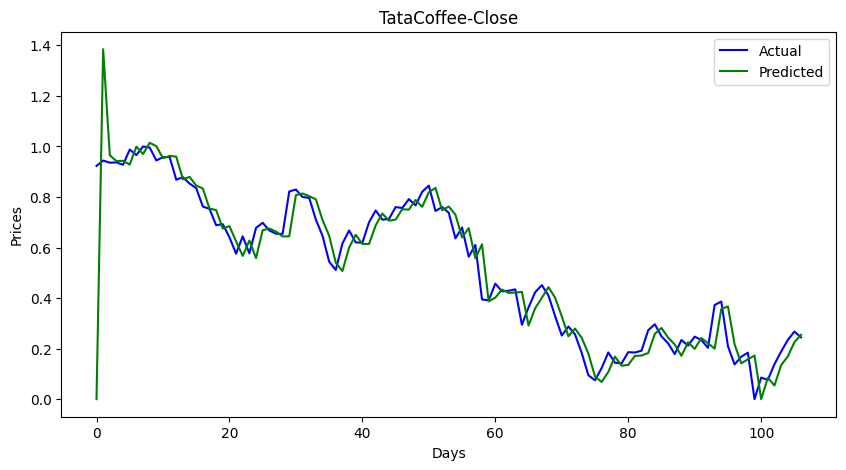

In [14]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [15]:
len(data1)

107

In [16]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [17]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

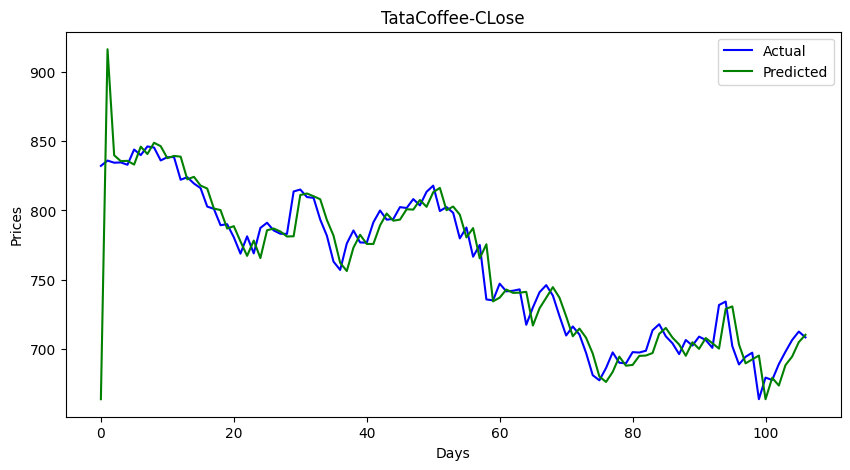

In [18]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [20]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def rmsemape_local(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"RMSE-Testset: {rmse}")
    print(f"maPe-Testset: {mape}")

rmsemape_local(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 21.5383019430507
maPe-Testset: 0.014492952237937798


In [21]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [22]:
forecast

array([0.23873566, 0.23372149, 0.22644994, 0.22044669])

In [23]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [24]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [25]:
forecast_stock_price_test_oriF

,Closefore
0,707.067582
1,706.150412
2,704.820334
3,703.722246
